# Castro Galante - Analítica Universitaria
## Insercion laboral formal y brechas de graduados universitarios en Argentina

**Trabajo practico final - Python - UTN**  
**Autor:** Carlos Jose Castro Galante  
**Enfoque del proyecto:** analisis exploratorio y visual de una problematica universitaria actual con alcance nacional.
**Repositorio del proyecto:** https://github.com/carlosjcastro/castro-galante-analitica-universitaria

---

### Idea del proyecto
Este trabajo no busca resolver un problema academico abstracto ni repetir un ejemplo clasico. La propuesta es construir una radiografia de la **insercion laboral formal de graduados universitarios argentinos**, con foco en desigualdades de gestion, genero, region y disciplina.

El objetivo es que el analisis sirva para:
- cumplir la consigna del trabajo practico,
- convertirse en una pieza de portfolio seria y reutilizable,
- dejar una base de codigo prolija para evolucionar luego a un dashboard o frontend.

### Dataset elegido
Se utiliza la base publica **Graduados universitarios del sistema Araucano (2016-2018)**, publicada por CEP XXI sobre datos de la SPU y registros del SIPA. Cada fila representa a una persona graduada y su situacion de empleo asalariado formal en 2019, 2020 o 2021.

### Hipotesis y preguntas de interes
1. **¿Como evoluciono la insercion laboral formal entre 2019 y 2021?**
2. **¿Existen diferencias entre graduados de instituciones estatales y privadas?**
3. **¿Que disciplinas muestran mejor equilibrio entre insercion formal y salario mediano?**
4. **¿Como se expresa la brecha de genero dentro de cada tipo de gestion?**
5. **¿Que regiones presentan mayor vulnerabilidad en insercion laboral formal?**

> Nota metodologica: los salarios estan expresados en **pesos corrientes** del mes de noviembre de cada anio. Por ese motivo, en este trabajo los salarios se comparan principalmente **dentro del mismo anio (2021)**, evitando interpretaciones engañosas entre años por efecto inflacionario.


In [ ]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuracion visual general
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

RUTA_NOTEBOOK = Path.cwd()
RUTA_PROYECTO = RUTA_NOTEBOOK.parent
RUTA_DATA = RUTA_PROYECTO / 'data' / 'raw'
RUTA_SALIDA = RUTA_PROYECTO / 'outputs' / 'figuras'
RUTA_SRC = RUTA_PROYECTO / 'src'

if str(RUTA_SRC) not in sys.path:
    sys.path.append(str(RUTA_SRC))

from analisis_utils import (
    PALETA,
    cargar_dataset,
    cargar_diccionarios,
    enriquecer_dataset,
    porcentaje_faltantes,
    tabla_resumen_2021,
    construir_indice_oportunidad,
    formatear_pesos,
)

RUTA_SALIDA.mkdir(parents=True, exist_ok=True)

print('Proyecto:', RUTA_PROYECTO)
print('Datos:', RUTA_DATA)
print('Salida de figuras:', RUTA_SALIDA)

Proyecto: c:\Users\carlo\OneDrive\Documentos\Proyectos\radar-universitario\radar-universitario-fullstack\analitica-notebooks
Datos: c:\Users\carlo\OneDrive\Documentos\Proyectos\radar-universitario\radar-universitario-fullstack\analitica-notebooks\data\raw
Salida de figuras: c:\Users\carlo\OneDrive\Documentos\Proyectos\radar-universitario\radar-universitario-fullstack\analitica-notebooks\outputs\figuras


## 1. Carga de datos
Se carga el dataset principal y el diccionario de codigos. Luego se enriquecen las variables para trabajar con etiquetas legibles y con nuevas columnas derivadas, como `empleo_formal`, `edad` y `edad_al_egreso`.

In [ ]:
ruta_dataset = RUTA_DATA / 'base_araucano.csv'
ruta_diccionario = RUTA_DATA / 'diccionario_araucano.xlsx'

df = cargar_dataset(ruta_dataset)
diccionarios = cargar_diccionarios(ruta_diccionario)
df = enriquecer_dataset(df, diccionarios)

print(f'Filas y columnas: {df.shape[0]:,} x {df.shape[1]}')
print(f'Personas unicas: {df["id"].nunique():,}')
print(f'Anios disponibles: {sorted(df["anio"].unique().tolist())}')
print(f'Anios de egreso: {sorted(df["anioegreso"].unique().tolist())}')

df.head()

Filas y columnas: 820,335 x 25
Personas unicas: 273,445
Anios disponibles: [2019, 2020, 2021]
Anios de egreso: [2016, 2017, 2018]


,id,rama_id,disciplina_id,tipo_titulo_id,gestion_id,genero_id,region_id,tamaño_id,letra_id,salario,anio,anioegreso,anionac,rama,disciplina,tipo_titulo,gestion,genero,region,tamaño,letra,empleo_formal,edad,edad_al_egreso,tramo_edad_egreso
0,1,1,1,4,1,1,1,NaN,NaN,NaN,2019,2017,"1,976.000",Ciencias Sociales,Economía y Administración,Posgrado,estatal,mujer,CABA,NaN,NaN,0,43.000,41.000,35-44
1,1,1,1,4,1,1,1,NaN,NaN,NaN,2020,2017,"1,976.000",Ciencias Sociales,Economía y Administración,Posgrado,estatal,mujer,CABA,NaN,NaN,0,44.000,41.000,35-44
2,1,1,1,4,1,1,1,NaN,NaN,NaN,2021,2017,"1,976.000",Ciencias Sociales,Economía y Administración,Posgrado,estatal,mujer,CABA,NaN,NaN,0,45.000,41.000,35-44
3,2,1,1,4,1,1,2,NaN,NaN,NaN,2019,2018,"1,980.000",Ciencias Sociales,Economía y Administración,Posgrado,estatal,mujer,BUENOS AIRES,NaN,NaN,0,39.000,38.000,35-44
4,2,1,1,4,1,1,2,NaN,NaN,NaN,2020,2018,"1,980.000",Ciencias Sociales,Economía y Administración,Posgrado,estatal,mujer,BUENOS AIRES,NaN,NaN,0,40.000,38.000,35-44


## 2. Chequeo de integridad y limpieza
En esta etapa se valida lo pedido por la consigna: estructura, tipos de datos, faltantes, duplicados y coherencia general.

### Decisiones tomadas
- **No se eliminan** las filas sin salario, porque en este dataset representan personas sin registro de empleo asalariado formal en SIPA para ese año.
- Se valida que no existan duplicados por combinacion `id y anio`.
- Se conserva `anionac` aunque tenga un porcentaje muy bajo de faltantes, ya que sigue siendo util para derivar edad y no compromete el analisis general.


In [ ]:
resumen_tipos = pd.DataFrame({
    'columna': df.columns,
    'tipo_dato': df.dtypes.astype(str).values,
    'nulos': df.isna().sum().values,
    'nulos_pct': (df.isna().mean() * 100).round(2).values,
    'valores_unicos': df.nunique(dropna=False).values,
}).sort_values('nulos_pct', ascending=False)

resumen_tipos

,columna,tipo_dato,nulos,nulos_pct,valores_unicos
8,letra_id,float64,341732,41.660,21
20,letra,str,341732,41.660,21
7,tamaño_id,float64,341616,41.640,5
9,salario,float64,341616,41.640,373744
19,tamaño,str,341616,41.640,5
12,anionac,float64,1188,0.140,61
24,tramo_edad_egreso,category,1188,0.140,6
23,edad_al_egreso,float64,1188,0.140,63
22,edad,float64,1188,0.140,63
5,genero_id,int64,0,0.000,2


In [ ]:
duplicados_id_anio = df.duplicated(subset=['id', 'anio']).sum()
faltantes = porcentaje_faltantes(df)

print(f'Duplicados por id y anio: {duplicados_id_anio}')
print('\nPorcentaje de faltantes por columna:')
faltantes

Duplicados por id y anio: 0

Porcentaje de faltantes por columna:


,columna,porcentaje_faltante
0,letra_id,41.658
1,letra,41.658
2,tamaño_id,41.643
3,salario,41.643
4,tamaño,41.643
5,anionac,0.145
6,tramo_edad_egreso,0.145
7,edad_al_egreso,0.145
8,edad,0.145
9,genero_id,0.000


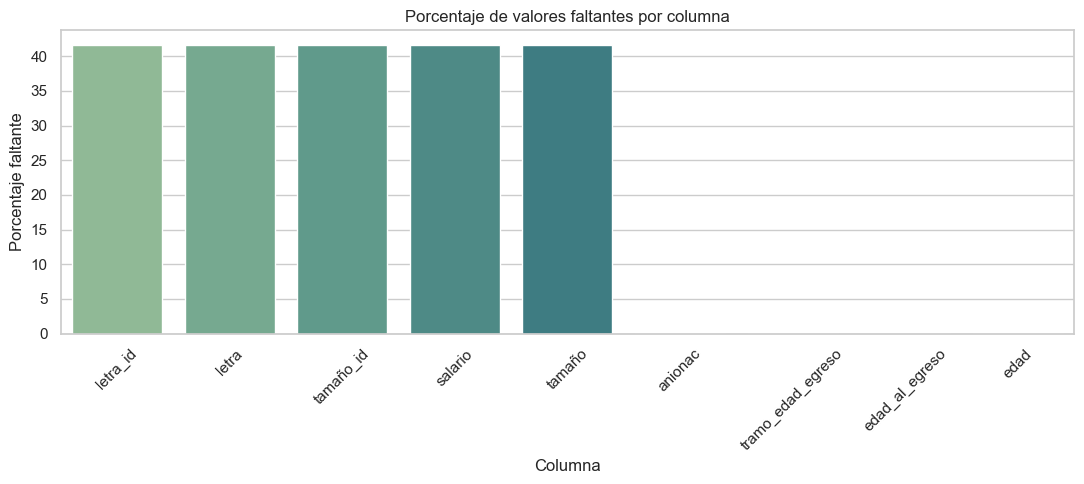

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_faltantes = faltantes[faltantes['porcentaje_faltante'] > 0].copy()
sns.barplot(
    data=plot_faltantes,
    x='columna',
    y='porcentaje_faltante',
    hue='columna',
    dodge=False,
    palette='crest',
    legend=False,
    ax=ax,
)
ax.set_title('Porcentaje de valores faltantes por columna')
ax.set_xlabel('Columna')
ax.set_ylabel('Porcentaje faltante')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(RUTA_SALIDA / '01_faltantes_por_columna.png', dpi=160, bbox_inches='tight')
plt.show()

## 3. Analisis exploratorio general (EDA)
Antes de responder las preguntas de interes, conviene observar algunas caracteristicas globales del dataset: distribuciones, edades, empleo formal y correlaciones numericas.

In [ ]:
# Resumen rapido
resumen_general = {
    'filas': len(df),
    'columnas': df.shape[1],
    'personas_unicas': df['id'].nunique(),
    'proporcion_empleo_formal_total': round(df['empleo_formal'].mean(), 3),
    'edad_al_egreso_mediana': round(df['edad_al_egreso'].median(), 1),
}
resumen_general

{'filas': 820335,
 'columnas': 25,
 'personas_unicas': 273445,
 'proporcion_empleo_formal_total': np.float64(0.584),
 'edad_al_egreso_mediana': np.float64(28.0)}

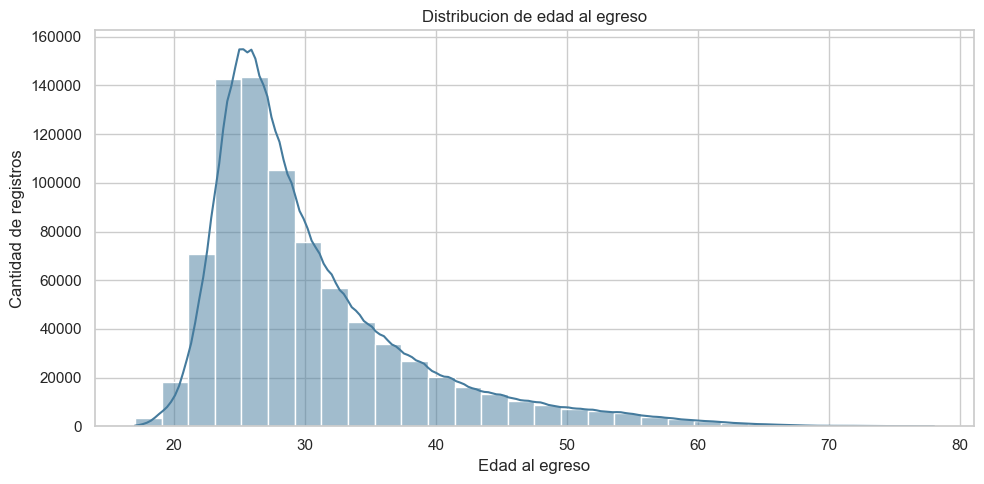

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['edad_al_egreso'].dropna(), bins=30, kde=True, color=PALETA['celeste'], ax=ax)
ax.set_title('Distribucion de edad al egreso')
ax.set_xlabel('Edad al egreso')
ax.set_ylabel('Cantidad de registros')
plt.tight_layout()
plt.savefig(RUTA_SALIDA / '02_distribucion_edad_egreso.png', dpi=160, bbox_inches='tight')
plt.show()

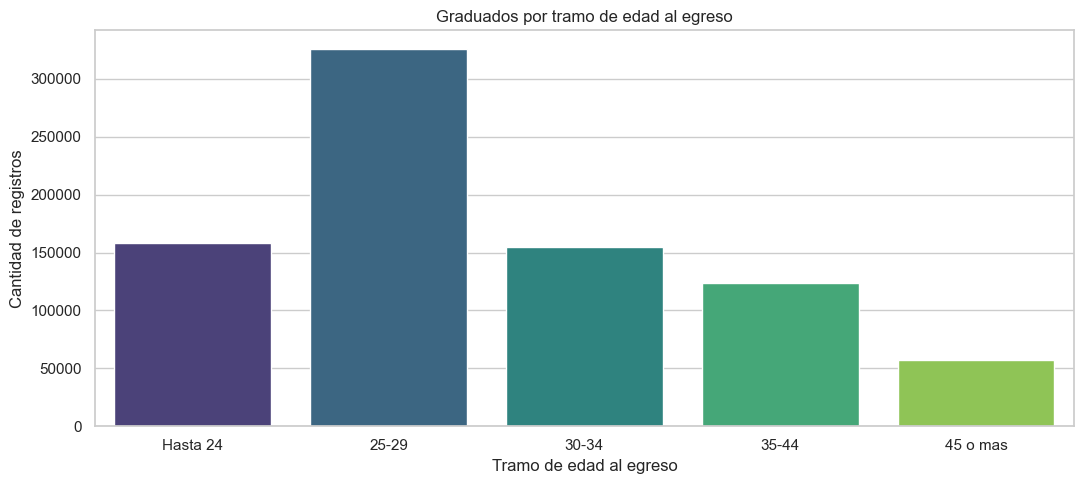

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
orden_tramos = ['Hasta 24', '25-29', '30-34', '35-44', '45 o mas']
sns.countplot(
    data=df,
    x='tramo_edad_egreso',
    order=orden_tramos,
    hue='tramo_edad_egreso',
    dodge=False,
    palette='viridis',
    legend=False,
    ax=ax,
)
ax.set_title('Graduados por tramo de edad al egreso')
ax.set_xlabel('Tramo de edad al egreso')
ax.set_ylabel('Cantidad de registros')
plt.tight_layout()
plt.savefig(RUTA_SALIDA / '03_tramos_edad_egreso.png', dpi=160, bbox_inches='tight')
plt.show()

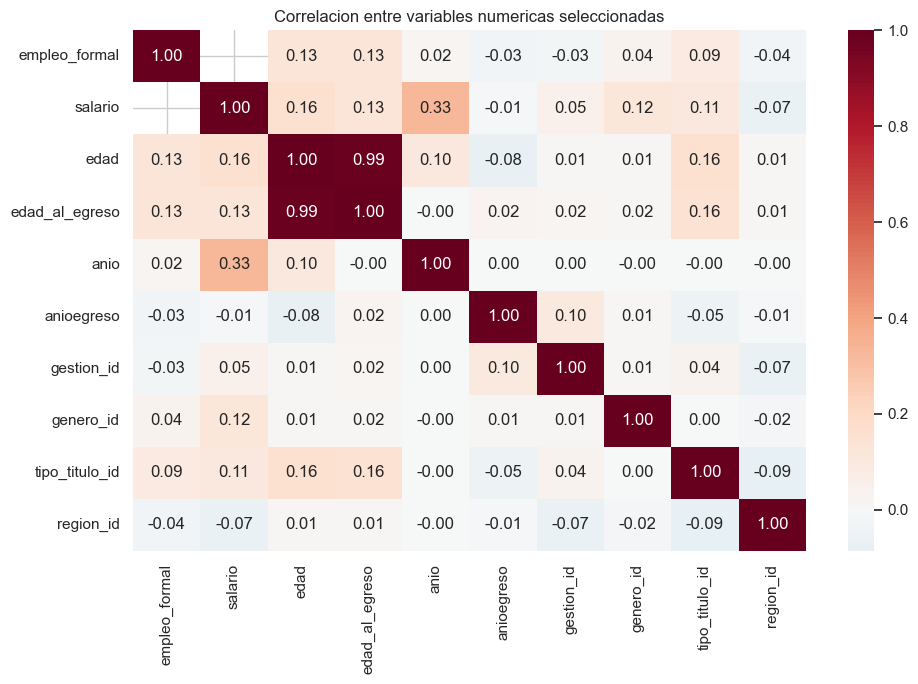

In [ ]:
columnas_corr = ['empleo_formal', 'salario', 'edad', 'edad_al_egreso', 'anio', 'anioegreso', 'gestion_id', 'genero_id', 'tipo_titulo_id', 'region_id']
matriz_corr = df[columnas_corr].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlacion entre variables numericas seleccionadas')
plt.tight_layout()
plt.savefig(RUTA_SALIDA / '04_matriz_correlacion.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Pregunta 1
### ¿Como evoluciono la insercion laboral formal entre 2019 y 2021?
Se analiza la proporcion de personas con registro de empleo asalariado formal en cada año disponible.

In [ ]:
evolucion_empleo = (
    df.groupby('anio', as_index=False)
      .agg(tasa_empleo_formal=('empleo_formal', 'mean'), graduados=('id', 'count'))
)
evolucion_empleo['tasa_empleo_formal_pct'] = evolucion_empleo['tasa_empleo_formal'] * 100

evolucion_empleo

,anio,tasa_empleo_formal,graduados,tasa_empleo_formal_pct
0,2019,0.574,273445,57.399
1,2020,0.581,273445,58.091
2,2021,0.596,273445,59.579


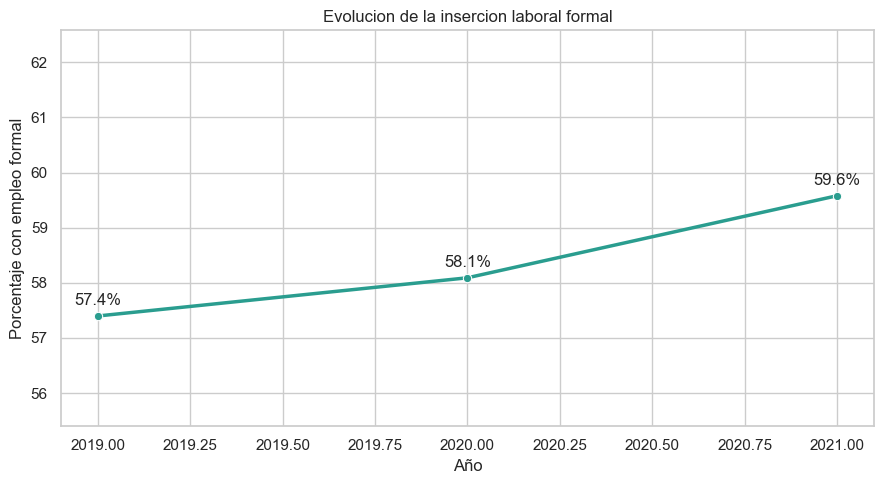

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(
    data=evolucion_empleo,
    x='anio',
    y='tasa_empleo_formal_pct',
    marker='o',
    linewidth=2.5,
    color=PALETA['verde'],
    ax=ax,
)
for _, fila in evolucion_empleo.iterrows():
    ax.text(fila['anio'], fila['tasa_empleo_formal_pct'] + 0.2, f"{fila['tasa_empleo_formal_pct']:.1f}%", ha='center')
ax.set_title('Evolucion de la insercion laboral formal')
ax.set_xlabel('Año')
ax.set_ylabel('Porcentaje con empleo formal')
ax.set_ylim(evolucion_empleo['tasa_empleo_formal_pct'].min() - 2, evolucion_empleo['tasa_empleo_formal_pct'].max() + 3)
plt.tight_layout()
plt.savefig(RUTA_SALIDA / '05_evolucion_empleo_formal.png', dpi=160, bbox_inches='tight')
plt.show()

**Lectura rapida:** la insercion laboral formal muestra una mejora moderada entre 2019 y 2021. Esto no implica causalidad ni refleja trabajo informal, independiente o no registrado; solo registra empleo asalariado formal presente en SIPA.

## 5. Pregunta 2
### ¿Existen diferencias entre graduados de instituciones estatales y privadas en 2021?
Como los salarios estan en pesos corrientes, el corte principal para comparar salarios se hace dentro de **2021**.

In [ ]:
resumen_gestion_2021 = tabla_resumen_2021(df, 'gestion').reset_index()
resumen_gestion_2021['tasa_empleo_formal_pct'] = resumen_gestion_2021['tasa_empleo_formal'] * 100
resumen_gestion_2021

,gestion,graduados,tasa_empleo_formal,salario_mediano,tasa_empleo_formal_pct
0,estatal,216314,0.605,"116,461.245",60.526
1,privada,57131,0.560,"131,850.000",55.996


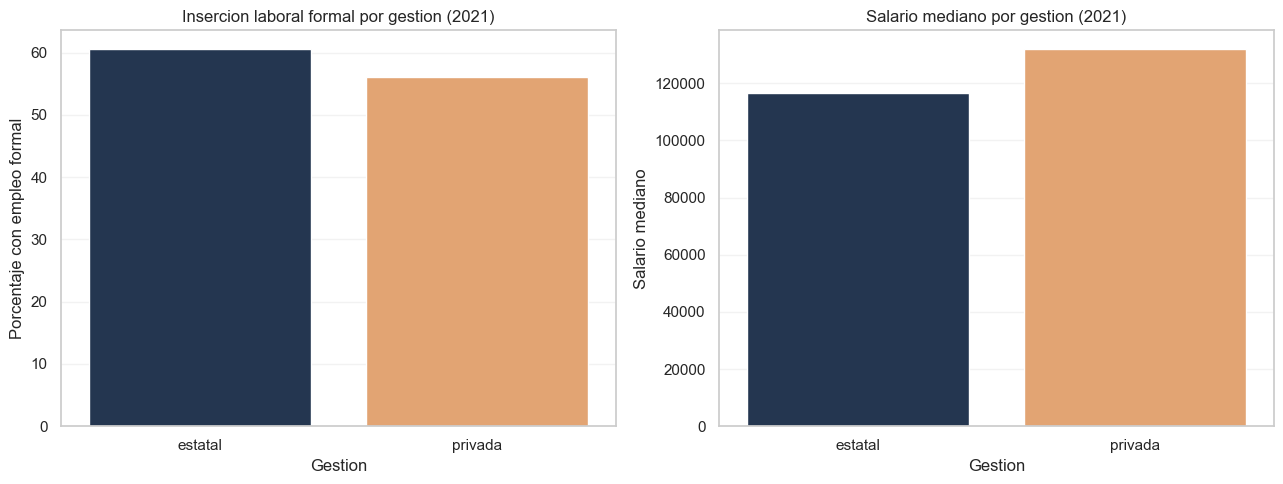

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=resumen_gestion_2021,
    x='gestion',
    y='tasa_empleo_formal_pct',
    hue='gestion',
    dodge=False,
    palette=[PALETA['azul'], PALETA['naranja']],
    legend=False,
    ax=axes[0],
)
axes[0].set_title('Insercion laboral formal por gestion (2021)')
axes[0].set_xlabel('Gestion')
axes[0].set_ylabel('Porcentaje con empleo formal')

sns.barplot(
    data=resumen_gestion_2021,
    x='gestion',
    y='salario_mediano',
    hue='gestion',
    dodge=False,
    palette=[PALETA['azul'], PALETA['naranja']],
    legend=False,
    ax=axes[1],
)
axes[1].set_title('Salario mediano por gestion (2021)')
axes[1].set_xlabel('Gestion')
axes[1].set_ylabel('Salario mediano')

for ax in axes:
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig(RUTA_SALIDA / '06_gestion_empleo_salario_2021.png', dpi=160, bbox_inches='tight')
plt.show()

**Lectura rapida:** en 2021, la gestion estatal muestra una mayor tasa de insercion formal, mientras que la privada presenta un salario mediano mas alto entre quienes tienen empleo asalariado formal. Esta diferencia vuelve interesante el analisis combinado de insercion y remuneracion.

## 6. Pregunta 3
### ¿Que disciplinas muestran mejor equilibrio entre insercion laboral formal y salario mediano?
Para evitar una mirada reducida, se construye un **Indice de Oportunidad** propio. Este indice combina:
- 55% de peso para la tasa de empleo formal,
- 45% de peso para el salario mediano,
- y se calcula solo sobre disciplinas con al menos 1.000 registros en 2021.

No pretende establecer un ranking absoluto de carreras, sino una herramienta exploratoria para comparar resultados laborales relativos dentro del dataset.

In [ ]:
df_2021 = df[df['anio'] == 2021].copy()
indice_disciplinas = construir_indice_oportunidad(df_2021, minimo_graduados=1000)

indice_disciplinas[['graduados', 'rama', 'tasa_empleo_formal', 'salario_mediano', 'indice_oportunidad']].head(12)

,graduados,rama,tasa_empleo_formal,salario_mediano,indice_oportunidad
disciplina,,,,,
Informática,7725,Ciencias Aplicadas,0.689,"182,506.980",86.449
Ingeniería,14783,Ciencias Aplicadas,0.678,"152,277.300",75.323
Otras Ciencias Sociales,2188,Ciencias Sociales,0.810,"113,676.195",73.677
Industrias,13187,Ciencias Aplicadas,0.674,"138,550.000",70.351
"Ciencias Políticas, Relaciones Internacionales y Diplomacia",2967,Ciencias Sociales,0.686,"134,691.180",70.065
Historia,1608,Ciencias Humanas,0.847,"92,418.398",69.721
Educación,15383,Ciencias Humanas,0.806,"100,362.675",68.832
Relaciones Institucionales y Humanas,4508,Ciencias Sociales,0.681,"124,650.125",66.339
Bioquímica y Farmacia,4574,Ciencias Aplicadas,0.633,"132,164.940",64.698


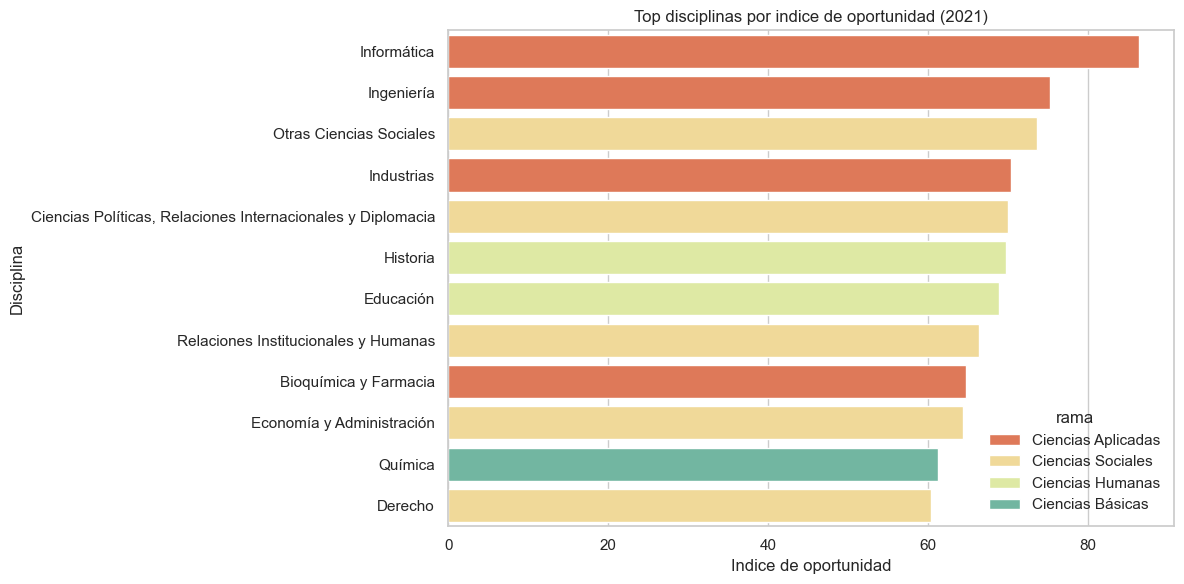

In [ ]:
top_indice = indice_disciplinas.head(12).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=top_indice,
    y='disciplina',
    x='indice_oportunidad',
    hue='rama',
    dodge=False,
    palette='Spectral',
    ax=ax,
)
ax.set_title('Top disciplinas por indice de oportunidad (2021)')
ax.set_xlabel('Indice de oportunidad')
ax.set_ylabel('Disciplina')
plt.tight_layout()
plt.savefig(RUTA_SALIDA / '07_top_indice_oportunidad.png', dpi=160, bbox_inches='tight')
plt.show()

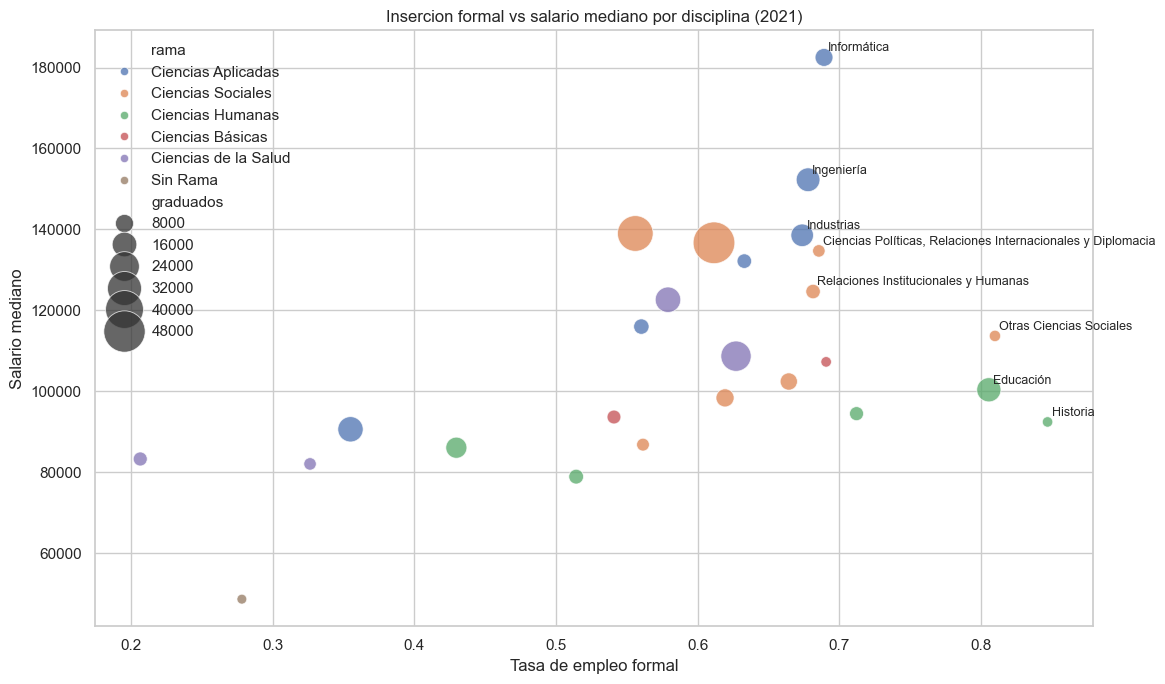

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
scatter = sns.scatterplot(
    data=indice_disciplinas.reset_index(),
    x='tasa_empleo_formal',
    y='salario_mediano',
    size='graduados',
    hue='rama',
    sizes=(50, 900),
    alpha=0.75,
    ax=ax,
)

for _, fila in indice_disciplinas.head(8).reset_index().iterrows():
    ax.text(fila['tasa_empleo_formal'] + 0.003, fila['salario_mediano'] + 1500, fila['disciplina'], fontsize=9)

ax.set_title('Insercion formal vs salario mediano por disciplina (2021)')
ax.set_xlabel('Tasa de empleo formal')
ax.set_ylabel('Salario mediano')
plt.tight_layout()
plt.savefig(RUTA_SALIDA / '08_scatter_disciplinas.png', dpi=160, bbox_inches='tight')
plt.show()

**Lectura rapida:** el cruce entre empleo formal y salario muestra que algunas disciplinas son fuertes en insercion, otras en remuneracion, y unas pocas logran un equilibrio destacado. Este tipo de lectura es mas util para politicas y orientacion que mirar una sola metrica aislada.

## 7. Pregunta 4
### ¿Como se expresa la brecha de genero dentro de cada tipo de gestion?
Se analiza la combinacion de genero y gestion para observar si la brecha salarial y de insercion cambia segun el tipo de institucion.

In [ ]:
brecha_genero_gestion = (
    df_2021.groupby(['gestion', 'genero'])
          .agg(
              graduados=('id', 'count'),
              tasa_empleo_formal=('empleo_formal', 'mean'),
              salario_mediano=('salario', 'median'),
          )
          .reset_index()
)
brecha_genero_gestion['tasa_empleo_formal_pct'] = brecha_genero_gestion['tasa_empleo_formal'] * 100
brecha_genero_gestion

,gestion,genero,graduados,tasa_empleo_formal,salario_mediano,tasa_empleo_formal_pct
0,estatal,mujer,131292,0.592,"107,574.000",59.208
1,estatal,varon,85022,0.626,"132,575.520",62.561
2,privada,mujer,33973,0.550,"119,937.745",55.038
3,privada,varon,23158,0.574,"152,000.000",57.401


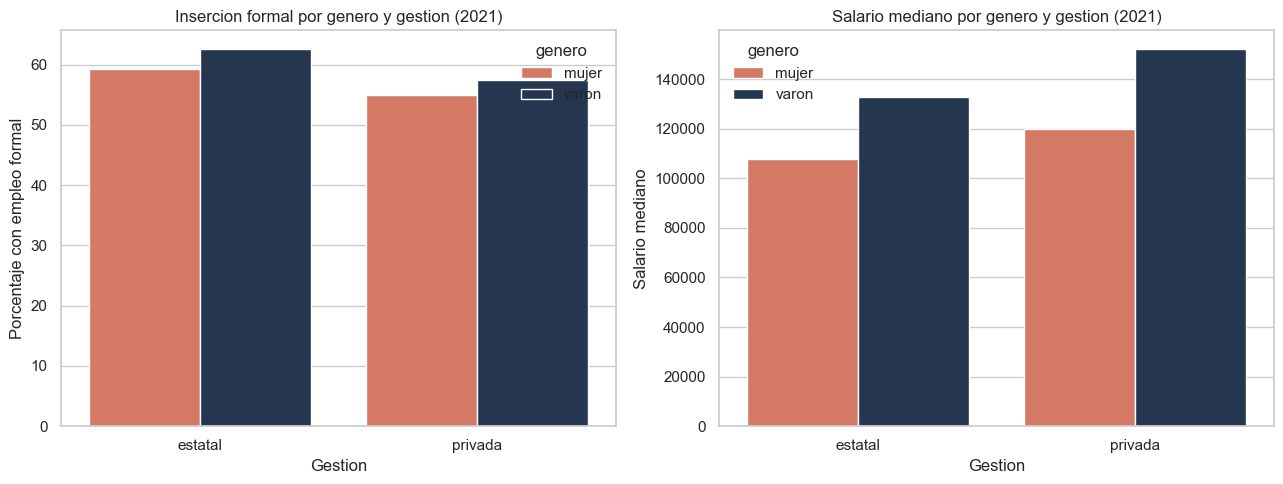

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=brecha_genero_gestion,
    x='gestion',
    y='tasa_empleo_formal_pct',
    hue='genero',
    palette=[PALETA['rojo'], PALETA['azul']],
    ax=axes[0],
)
axes[0].set_title('Insercion formal por genero y gestion (2021)')
axes[0].set_xlabel('Gestion')
axes[0].set_ylabel('Porcentaje con empleo formal')

sns.barplot(
    data=brecha_genero_gestion,
    x='gestion',
    y='salario_mediano',
    hue='genero',
    palette=[PALETA['rojo'], PALETA['azul']],
    ax=axes[1],
)
axes[1].set_title('Salario mediano por genero y gestion (2021)')
axes[1].set_xlabel('Gestion')
axes[1].set_ylabel('Salario mediano')

plt.tight_layout()
plt.savefig(RUTA_SALIDA / '09_genero_gestion_2021.png', dpi=160, bbox_inches='tight')
plt.show()

**Lectura rapida:** la brecha de genero aparece tanto en insercion laboral formal como en salario mediano, y persiste en ambas gestiones. Esto refuerza la idea de que las trayectorias universitarias no se traducen en resultados laborales del mismo modo para todos los grupos.

## 8. Pregunta 5
### ¿Que regiones presentan mayor vulnerabilidad en insercion laboral formal?
La region se toma como variable clave porque ayuda a detectar desigualdades territoriales que pueden servir como insumo para universidades, areas de extension, observatorios y politicas publicas.

In [ ]:
resumen_region_2021 = tabla_resumen_2021(df, 'region').reset_index()
resumen_region_2021['tasa_empleo_formal_pct'] = resumen_region_2021['tasa_empleo_formal'] * 100
resumen_region_2021 = resumen_region_2021.sort_values('tasa_empleo_formal_pct', ascending=False)
resumen_region_2021

,region,graduados,tasa_empleo_formal,salario_mediano,tasa_empleo_formal_pct
0,CABA,67736,0.676,"147,909.165",67.645
1,PATAGONIA,14049,0.668,"144,002.800",66.845
2,CUYO,13884,0.653,"100,517.620",65.291
3,NOA,19905,0.588,"86,225.062",58.769
4,NEA,17089,0.586,"102,049.090",58.570
5,BUENOS AIRES,68007,0.580,"118,437.255",57.991
6,"RESTO PAMPEANA (SANTA FE, CORDOBA, ENTRE RIOS,...",72775,0.515,"103,898.810",51.523


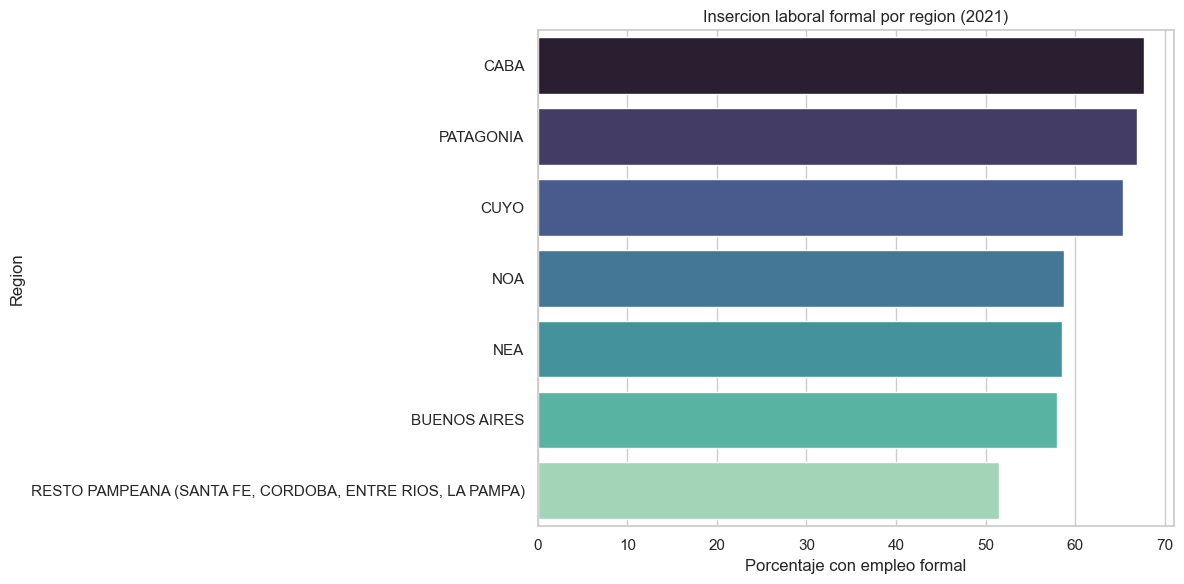

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=resumen_region_2021,
    y='region',
    x='tasa_empleo_formal_pct',
    hue='region',
    dodge=False,
    palette='mako',
    legend=False,
    ax=ax,
)
ax.set_title('Insercion laboral formal por region (2021)')
ax.set_xlabel('Porcentaje con empleo formal')
ax.set_ylabel('Region')
plt.tight_layout()
plt.savefig(RUTA_SALIDA / '10_region_empleo_formal_2021.png', dpi=160, bbox_inches='tight')
plt.show()

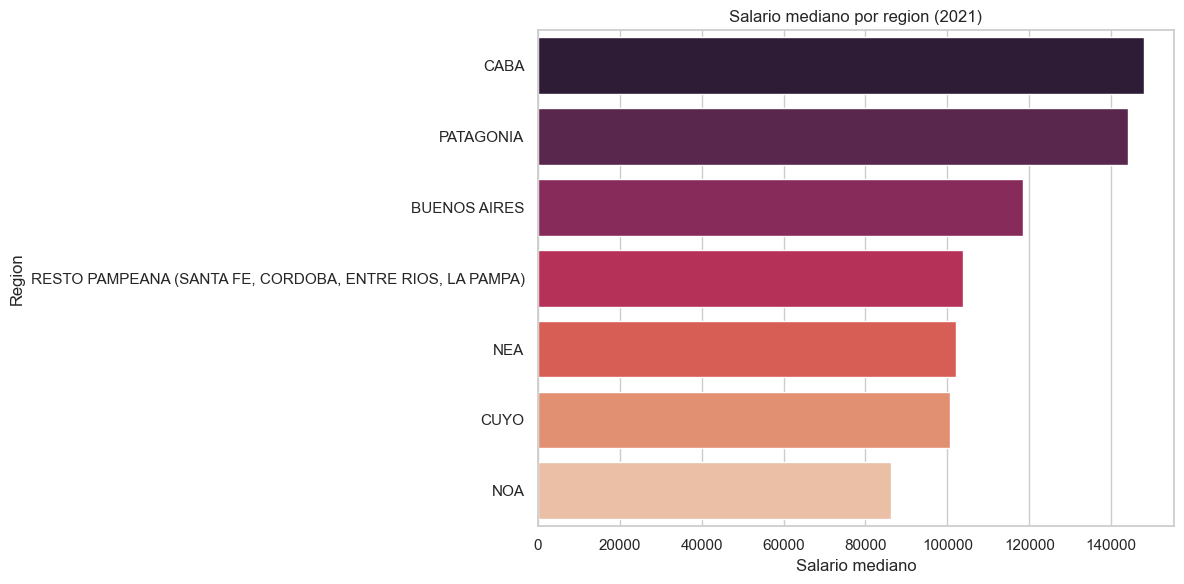

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=resumen_region_2021.sort_values('salario_mediano', ascending=False),
    y='region',
    x='salario_mediano',
    hue='region',
    dodge=False,
    palette='rocket',
    legend=False,
    ax=ax,
)
ax.set_title('Salario mediano por region (2021)')
ax.set_xlabel('Salario mediano')
ax.set_ylabel('Region')
plt.tight_layout()
plt.savefig(RUTA_SALIDA / '11_region_salario_2021.png', dpi=160, bbox_inches='tight')
plt.show()

## 9. Hallazgos principales
A continuacion se resumen los resultados mas importantes del trabajo. Los valores se interpretan siempre dentro de los limites del dataset: empleo asalariado formal registrado y salarios corrientes de noviembre de cada año.

In [ ]:
empleo_2019 = df.loc[df['anio'] == 2019, 'empleo_formal'].mean() * 100
empleo_2021 = df.loc[df['anio'] == 2021, 'empleo_formal'].mean() * 100
mejora_pp = empleo_2021 - empleo_2019

hallazgos = pd.DataFrame([
    {
        'hallazgo': 'Insercion formal 2019',
        'valor': f'{empleo_2019:.1f}%'
    },
    {
        'hallazgo': 'Insercion formal 2021',
        'valor': f'{empleo_2021:.1f}%'
    },
    {
        'hallazgo': 'Mejora entre 2019 y 2021',
        'valor': f'{mejora_pp:.1f} puntos porcentuales'
    },
    {
        'hallazgo': 'Gestion con mayor insercion formal en 2021',
        'valor': resumen_gestion_2021.sort_values('tasa_empleo_formal', ascending=False).iloc[0]['gestion']
    },
    {
        'hallazgo': 'Gestion con mayor salario mediano en 2021',
        'valor': resumen_gestion_2021.sort_values('salario_mediano', ascending=False).iloc[0]['gestion']
    },
    {
        'hallazgo': 'Disciplina lider del indice de oportunidad',
        'valor': indice_disciplinas.reset_index().iloc[0]['disciplina']
    },
    {
        'hallazgo': 'Region con menor insercion formal',
        'valor': resumen_region_2021.sort_values('tasa_empleo_formal').iloc[0]['region']
    },
])

hallazgos

,hallazgo,valor
0,Insercion formal 2019,57.4%
1,Insercion formal 2021,59.6%
2,Mejora entre 2019 y 2021,2.2 puntos porcentuales
3,Gestion con mayor insercion formal en 2021,estatal
4,Gestion con mayor salario mediano en 2021,privada
5,Disciplina lider del indice de oportunidad,Informática
6,Region con menor insercion formal,"RESTO PAMPEANA (SANTA FE, CORDOBA, ENTRE RIOS,..."


## 10. Conclusiones
Este trabajo muestra que una misma trayectoria universitaria no se traduce en los mismos resultados laborales para todos los perfiles. Aun dentro de un mismo sistema de educacion superior aparecen diferencias claras por disciplina, region, genero y gestion.

### Conclusiones sinteticas
- La insercion laboral formal mejora entre 2019 y 2021, aunque de forma moderada.
- La gestion estatal presenta mejor insercion formal, pero la privada alcanza mayor salario mediano entre quienes tienen empleo registrado.
- Las disciplinas no pueden leerse solo por salario o solo por empleabilidad: el enfoque combinado resulta mas informativo.
- Las brechas de genero siguen visibles incluso al separar por gestion.
- Las diferencias regionales son suficientemente marcadas como para justificar analisis y politicas especificas.

### Valor agregado del proyecto
- Se cumple la consigna tecnica del trabajo practico.
- Se trabaja sobre una problematica universitaria real y actual.
- Se deja una base reutilizable para evolucionar a un dashboard con Streamlit, Power BI o un frontend web.
- El proyecto puede ser mostrado tanto en GitHub como en un portfolio profesional.

### Posibles mejoras futuras
- Ajustar salarios por inflacion para comparaciones interanuales mas robustas.
- Incorporar un tablero interactivo.
- Sumar segmentacion por tipo de titulo, rama o tamaño de empresa.
- Entrenar un modelo sencillo de clasificacion para estimar probabilidad de empleo formal, siempre con advertencias metodologicas y eticas.
